## 1. Imports

In [1]:
import karateclub as kc
import networkx as nx
import numpy as np
import pandas as pd
import warnings

from notebook_utils import load_test_df, load_subject_df, compute_flow_trees_by_q, run_hypothesis_tests
from reeb_utils import extract_tree_features
from scipy import stats 
from scipy.spatial.distance import pdist


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

import logging
logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

## 2. Load data

In [2]:
test_df = load_test_df()
subject_df = load_subject_df()

merged_df = pd.merge(test_df, subject_df, on="Subject")

## 3. Compute Flow Trees

In [9]:
flow_trees_by_q, accs = compute_flow_trees_by_q(test_df)

## 4. Compute features

### Baselines

In [4]:
# baseline_features
baselines_by_q = []
for q in flow_trees_by_q:
    baselines = []
    for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
        euclid_distance = group["Euc.Distance"].mode().iloc[0]
        path_distance = group["Path.Distance"].mode().iloc[0]
        num_nodes = group["Num.Nodes"].mode().iloc[0]
        
        avg_path_dist_traveled = group["path_dist_trav"].mean()
        avg_nodes_count = group["nodes_count"].mean()
        avg_turns_count = group["turns_count"].mean()

        baselines.append([euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count])
    baselines_by_q.append(baselines)
baselines_by_q = np.array(baselines_by_q)

### Tree features

In [5]:
tree_features_by_q = []
for q in flow_trees_by_q:
    tree_features = np.array([extract_tree_features(ft, 0) for ft in flow_trees_by_q[q]])
    tree_features = (tree_features - tree_features.mean(axis=0)) / tree_features.std(axis=0)
    
    tree_features_by_q.append(tree_features)

tree_features_by_q = np.array(tree_features_by_q)

diameters_by_q = []
for q in flow_trees_by_q:
    tree_features = np.array([[nx.diameter(ft)] for ft in flow_trees_by_q[q]])
    # tree_features = (tree_features - tree_features.mean(axis=0)) / tree_features.std(axis=0)
    
    diameters_by_q.append(tree_features)

diameters_by_q = np.array(diameters_by_q)

### Tree embeddings

In [8]:
all_flow_trees = []
for q in flow_trees_by_q:
    all_flow_trees.extend(flow_trees_by_q[q])

explore_model = kc.Graph2Vec(dimensions=64)
explore_model.fit(all_flow_trees)
    
tree_embeddings_by_q = np.array([explore_model.infer(flow_trees_by_q[q]) for q in flow_trees_by_q])

### Tree shapes

In [11]:
max_num_nodes = max(all_flow_trees, key=lambda x: x.number_of_nodes()).number_of_nodes()

# convert Flow Trees to padded adjacency matrices
padded_adj_mats = []
for ft in all_flow_trees:
    adj_mat = nx.adjacency_matrix(ft).todense()

    amt_to_pad = max_num_nodes - ft.number_of_nodes()
    padded_adj_mat = np.pad(adj_mat, pad_width=(0, amt_to_pad))

    padded_adj_mats.append(padded_adj_mat)

padded_adj_mats = np.array(padded_adj_mats)

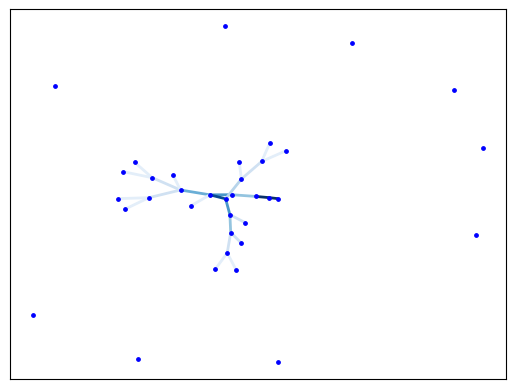

In [13]:
## STOLEN FROM GEOMSTATS DEMO
##  https://github.com/geomstats/geomstats/blob/main/notebooks/20_real_world_applications__graph_space.ipynb
import matplotlib.pyplot as plt
import networkx as nx

import geomstats.backend as gs
import geomstats.datasets.utils as data_utils
from geomstats.geometry.stratified.graph_space import GraphSpace
from geomstats.learning.aac import AAC

gs.random.seed(2020)

# Plot the 5th flow tree.
flow_tree_example = nx.from_numpy_array(padded_adj_mats[5])
pos = nx.kamada_kawai_layout(flow_tree_example)
edges, weights = zip(*nx.get_edge_attributes(flow_tree_example, "weight").items())

pos = nx.spring_layout(flow_tree_example)
nx.draw_networkx_nodes(flow_tree_example, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    flow_tree_example,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

# normal to have all the floating nodes; this is what happens when you are padded

In [15]:
# Compute mean flow tree.
total_space = GraphSpace(n_nodes=padded_adj_mats.shape[1])
total_space.equip_with_group_action()
total_space.equip_with_quotient()

aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=100)
aac_fm.fit(padded_adj_mats)

_AACFrechetMean(max_iter=100,
                space=<geomstats.geometry.stratified.graph_space.GraphSpace object at 0x16f9007d0>,
                total_space_estimator_kwargs={})

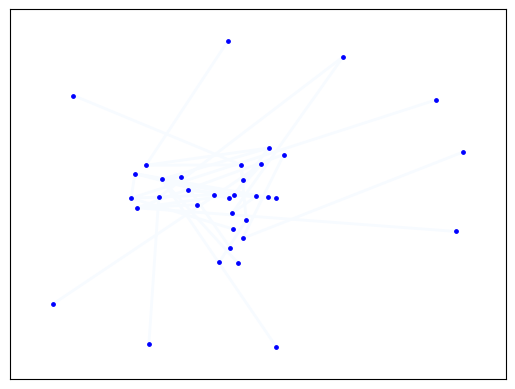

In [16]:
# Plot mean.
total_flow_trees_fm_mst = nx.minimum_spanning_tree(nx.from_numpy_array(aac_fm.estimate_))
edges, weights = zip(*nx.get_edge_attributes(total_flow_trees_fm_mst, "weight").items())

nx.draw_networkx_nodes(total_flow_trees_fm_mst, pos, node_color="b", node_size=6)
nx.draw_networkx_edges(
    total_flow_trees_fm_mst,
    pos,
    edgelist=edges,
    edge_color=weights,
    width=2.0,
    edge_cmap=plt.cm.Blues,
    edge_vmin=0.0,
    edge_vmax=10.0,
)

In [18]:
# make sure metrics make sense
graph_space = total_space.quotient

point_a, point_b, point_c = padded_adj_mats[0], padded_adj_mats[1], padded_adj_mats[-1]

dist_total = total_space.metric.dist(point_a, point_b)
dist_quotient = graph_space.metric.dist(point_a, point_b)

print(f"dist quotient <= dist total:\n{dist_quotient} <= {dist_total}")

print("dist a to c", graph_space.metric.dist(point_a, point_c))

dist quotient <= dist total:
23.15167380558045 <= 29.257477676655586
dist a to c 21.95449840010015


## 5. Hypothesis testing

In [7]:
print("Baselines:")
run_hypothesis_tests(baselines_by_q)
print()

print("Tree features:")
run_hypothesis_tests(tree_features_by_q)
print()

print("Tree diameters:")
run_hypothesis_tests(diameters_by_q)
print()

print("Tree embeddings:")
run_hypothesis_tests(tree_embeddings_by_q)
print()


Baselines:
T-statistic: -0.6890654515540531, P-value: 0.49078466201487525
Permutation test: statistic=0.00, p=0.0002

Tree features:
T-statistic: 0.6821966119938591, P-value: 0.4951171886322788
Permutation test: statistic=0.00, p=0.0002

Tree diameters:
T-statistic: 63.16487918531403, P-value: 0.0
Permutation test: statistic=4.88, p=0.0002

Tree embeddings:
T-statistic: 61.53684081230195, P-value: 0.0
Permutation test: statistic=0.45, p=0.0002



### Tiny bit more complicated for shapes
because mean doesn't make sense (didn't converge)

In [20]:
def flatten_mats(mats):
    flat_mats = np.zeros((mats.shape[0], mats.shape[1]*mats.shape[2]))
    for i, m in enumerate(mats):
        flat_mats[i,:] = m.flatten()
    return flat_mats

def unflatten_mat(mat):
    d1_size = int(np.sqrt(mat.shape[0]))
    if d1_size**2 != mat.shape[0]: 
        print("uhoh mats isn't a square matrix")
        return

    return np.reshape(mat, (d1_size, d1_size))
    
def dist_metric_with_flat(m1, m2):
    unflat_m1 = unflatten_mat(m1)
    unflat_m2 = unflatten_mat(m2)

    return graph_space.metric.dist(unflat_m1, unflat_m2)

In [21]:
num_in_half = padded_adj_mats.shape[0]//2
q12_flow_trees = padded_adj_mats[:num_in_half, :, :]
q34_flow_trees = padded_adj_mats[num_in_half:, :, :]
    
flat_all = flatten_mats(padded_adj_mats)
flat_q12 = flatten_mats(q12_flow_trees)
flat_q34 = flatten_mats(q34_flow_trees)

between_group_dist = [] #pdist(flat_all, metric=dist_metric_with_flat)
for f1 in flat_q12:
    for f3 in flat_q34:
        between_group_dist.append(dist_metric_with_flat(f1, f3))
between_group_dist = np.array(between_group_dist)

q12_dist = pdist(flat_q12, metric=dist_metric_with_flat)
q34_dist = pdist(flat_q34, metric=dist_metric_with_flat)

In [22]:
between_group_dist = np.array(between_group_dist)

print(np.concatenate([q12_dist, q34_dist]).shape)
print(between_group_dist.shape)

(20592,)
(20736,)


In [23]:
# Perform a t-test on distances between the two groups
t_stat, p_value = stats.ttest_ind(between_group_dist, np.concatenate([q12_dist, q34_dist]))
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 29.41889357217279, P-value: 2.7763264162886665e-188


In [24]:
print("mean pairwise between group dist:", np.mean(between_group_dist), "+-", np.std(between_group_dist))
print("mean pairwise within group dist:", np.mean(np.concatenate([q12_dist, q34_dist])), "+-", np.std(np.concatenate([q12_dist, q34_dist])))

mean pairwise between group dist: 21.68896096992515 +- 6.514454948775942
mean pairwise within group dist: 19.631803022010185 +- 7.658531870782548


In [25]:
num_in_half = padded_adj_mats.shape[0]//2
x = padded_adj_mats[:num_in_half, :, :]
y = padded_adj_mats[num_in_half:, :, :]

def statistic(x, y):#, axis):
    if len(x.shape) == 1: return 0
    if x.shape[0] == 36:
        print("ghi")
        print(x.shape)
        total_space = GraphSpace(n_nodes=x.shape[1])
        total_space.equip_with_group_action()
        total_space.equip_with_quotient()
        
        graph_space = total_space.quotient

        x = np.reshape(x, (x.shape[2],x.shape[0],x.shape[1]))
        y = np.reshape(y, (y.shape[2],y.shape[0],y.shape[1]))

        
        # print(x.shape)
        # print(x[0].shape)
        aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=50)
        aac_fm.fit(x)

        mean_x = aac_fm.estimate_
    
        print(y.shape)
        aac_fm.fit(y)
        mean_y = aac_fm.estimate_

        # Calculate Frechet distance
        return graph_space.metric.dist(mean_x, mean_y)
        # return graph_space.metric.dist(x, y)

    print(x.shape)
    total_space = GraphSpace(n_nodes=x.shape[1])
    total_space.equip_with_group_action()
    total_space.equip_with_quotient()
    
    graph_space = total_space.quotient

    print(x.shape)
    aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=50)
    aac_fm.fit(x)
    mean_x = aac_fm.estimate_

    print(y.shape)
    aac_fm.fit(y)
    mean_y = aac_fm.estimate_
    
    # Calculate Frechet distance
    return graph_space.metric.dist(mean_x, mean_y)
    # return graph_space.metric.dist(x, y)

print(statistic(x,y))

# res = stats.permutation_test((x, y), statistic, n_resamples=999, axis=0,
#                        vectorized=False, alternative='two-sided')
# print(res.statistic)
# print(res.pvalue)

(144, 36, 36)
(144, 36, 36)


(144, 36, 36)


8.1857651776245


In [26]:
from sklearn.utils import shuffle

def permutation_test(x, y, total_space, num_permutations=1000):
    # Fit the original data and calculate the observed Fréchet distance
    aac_fm = AAC(total_space, estimate="frechet_mean", max_iter=50)
    
    # Compute Fréchet mean for the original group x
    aac_fm.fit(x)
    mean_x = aac_fm.estimate_
    
    # Compute Fréchet mean for the original group y
    aac_fm.fit(y)
    mean_y = aac_fm.estimate_
    
    # Calculate the observed Fréchet distance between the two groups
    observed_dist = total_space.quotient.metric.dist(mean_x, mean_y)
    
    # Combine x and y into a single dataset
    combined_data = np.concatenate([x, y], axis=0)
    
    # Number of samples in each group
    n_x = x.shape[0]
    n_y = y.shape[0]
    
    # List to store distances for each permutation
    permuted_dists = []
    
    # Perform permutations
    for i in range(num_permutations):
        # Shuffle the combined dataset
        shuffled_data = shuffle(combined_data)
        
        # Split the shuffled data into two new groups
        perm_x = shuffled_data[:n_x]
        perm_y = shuffled_data[n_x:]
        
        # Compute Fréchet mean for permuted group 1
        aac_fm.fit(perm_x)
        perm_mean_x = aac_fm.estimate_
        
        # Compute Fréchet mean for permuted group 2
        aac_fm.fit(perm_y)
        perm_mean_y = aac_fm.estimate_
        
        # Calculate the Fréchet distance between the two permuted groups
        perm_dist = total_space.quotient.metric.dist(perm_mean_x, perm_mean_y)
        permuted_dists.append(perm_dist)
    
    # Calculate the p-value: fraction of permuted distances >= observed distance
    p_value = np.sum(np.array(permuted_dists) >= observed_dist) / num_permutations
    
    return observed_dist, p_value

# Example usage:
# Assuming `x`, `y` are your input data, and `total_space` is an instance of GraphSpace

num_in_half = padded_adj_mats.shape[0]//2
x = padded_adj_mats[:num_in_half, :, :]
y = padded_adj_mats[num_in_half:, :, :]

total_space = GraphSpace(n_nodes=x.shape[1])
total_space.equip_with_group_action()
total_space.equip_with_quotient()

graph_space = total_space.quotient

observed_dist, p_value = permutation_test(x, y, total_space, 500)
print(f"Observed Fréchet Distance: {observed_dist}")
print(f"P-value from permutation test: {p_value}")


KeyboardInterrupt: 